In [36]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
MODEL_CHECKPOINT = MODEL_DIR + "best_model.pth"
MODEL_HISTORY = np.load(MODEL_DIR + "history.npy", allow_pickle=True).item()
BATCH_SIZE = 64
DO_SWEEP = False
STEP_FOR_RANK_SWEP_EVAL = 1

In [37]:
# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    pin_memory = True
    num_workers = 16
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    pin_memory = False
    num_workers = 0
    print("Using MPS")
else:
    device = torch.device("cpu")
    pin_memory = False
    print("Using CPU")

Using MPS


In [38]:
base_model = KWSBase(cfg).to(device)
base_model.load_state_dict(torch.load(MODEL_CHECKPOINT, map_location=device))

# print the model architecture and number of parameters
n_total = sum(p.numel() for p in base_model.parameters())
print(f"Base model parameters: {n_total}")


Base model parameters: 338718


In [39]:
#Datasets and dataloaders
data_dir = get_data_dir()
train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **noise_train_cfg.model_dump())
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, pin_memory = pin_memory, num_workers=num_workers)

val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **noise_eval_cfg.model_dump())
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory = pin_memory, num_workers=num_workers)

Adding noise: 100%|██████████| 4515/4515 [00:11<00:00, 384.13sample/s]


In [40]:
def validate_model(
    model: nn.Module,
    val_loader,
    criterion: nn.Module,
    device: torch.device,
    snr_values=None,
    verbose: bool = True,
    fixed_rank: Optional[int] = None,
) -> Tuple[
    Dict[Union[int, float, None], Dict[str, float]],
    List[Dict[str, Any]],
]:
    """
    Evaluate `model` on the validation set for different SNR values.

    Assumes:
        - val_loader.dataset._set_snr(snr) exists.
        - val_loader yields (waveforms, labels, meta).

    Returns:
        results:
            dict {snr: {"loss": float, "acc": float}}

        per_sample_records:
            list of dicts, one per sample, containing:
              - snr
              - rank
              - pred
              - target
              - correct
              - optional metadata fields if present:
                    label, utterance, noise_type, snr
    """
    if snr_values is None:
        snr_values = [None]

    model.eval()
    results: Dict[Union[int, float, None], Dict[str, float]] = {}
    per_sample_records: List[Dict[str, Any]] = []

    ds = val_loader.dataset

    def _get_meta_item(meta_val, i):
        if isinstance(meta_val, (list, tuple)):
            return meta_val[i]
        if torch.is_tensor(meta_val):
            v = meta_val[i]
            return v.item() if v.numel() == 1 else v.detach().cpu()
        return meta_val

    with torch.no_grad():
        for snr in snr_values:
            ds._set_snr(snr)

            total_loss = 0.0
            total_correct = 0
            total_samples = 0

            pbar = tqdm(val_loader, desc=f"SNR={snr}", leave=False)

            for waveforms, labels, meta in pbar:
                waveforms = waveforms.to(device)
                labels = labels.to(device)

                logits, embeddings = model(waveforms, ranks=fixed_rank, return_embedding=True)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                total_samples += batch_size
                total_loss += loss.item() * batch_size

                preds = logits.argmax(dim=1)
                correct_mask = preds == labels
                total_correct += int(correct_mask.sum().item())

                preds_cpu = preds.detach().cpu().tolist()
                labels_cpu = labels.detach().cpu().tolist()
                correct_cpu = correct_mask.detach().cpu().tolist()

                for i in range(batch_size):
                    rec = {
                        "snr_eval": snr, 
                        "rank": fixed_rank,
                        "pred": int(preds_cpu[i]),
                        "target": int(labels_cpu[i]),
                        "correct": bool(correct_cpu[i]),
                        "embedding": embeddings[i].detach().cpu().numpy(),
                    }

                    if isinstance(meta, dict):
                        for k in ["label", "utterance", "noise_type"]:
                            if k in meta:
                                rec[k] = _get_meta_item(meta[k], i)
                        if "snr" in meta:
                             rec["snr_sample"] = _get_meta_item(meta["snr"], i)

                    per_sample_records.append(rec)

                pbar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    acc=f"{100 * total_correct / total_samples:.2f}%",
                )

            avg_loss = total_loss / total_samples
            avg_acc = 100.0 * total_correct / total_samples
            results[snr] = {"loss": avg_loss, "acc": avg_acc}

            if verbose:
                print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

    return results, per_sample_records


In [41]:
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]
# deactivate low-rank everywhere
base_model.toggle_low_rank((False,False,False))
#full_rank_acc = validate_model(base_model, val_loader, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=None)
results, per_sample_records = validate_model(base_model, val_loader, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=None)
print(f"\n=== Full Rank Val Accuracy per SNR ===")
for snr, stats in results.items():
    print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
print("-" * 60)


=== Full Rank Val Accuracy per SNR ===
  SNR=    -5: acc=79.73%  loss=0.5906
  SNR=     0: acc=87.91%  loss=0.3598
  SNR=     5: acc=91.27%  loss=0.2692
  SNR=    10: acc=92.96%  loss=0.2269
  SNR=    15: acc=93.64%  loss=0.2058
  SNR=   inf: acc=95.22%  loss=0.1841
------------------------------------------------------------


In [42]:
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]
# deactivate low-rank everywhere
base_model.toggle_low_rank((True,True,True))
#full_rank_acc = validate_model(base_model, val_loader, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=None)
results, per_sample_records = validate_model(base_model, val_loader, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=64)
print(f"\n=== 64 Rank Val Accuracy per SNR ===")
for snr, stats in results.items():
    print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
print("-" * 60)


=== 64 Rank Val Accuracy per SNR ===
  SNR=    -5: acc=79.84%  loss=0.5956
  SNR=     0: acc=87.69%  loss=0.3622
  SNR=     5: acc=91.25%  loss=0.2715
  SNR=    10: acc=93.00%  loss=0.2287
  SNR=    15: acc=93.55%  loss=0.2065
  SNR=   inf: acc=95.08%  loss=0.1861
------------------------------------------------------------


In [43]:
def evaluate_rank_sweep(
    model: nn.Module,
    validate_fn,
    val_loader,
    criterion: nn.Module,
    device: torch.device,
    *,
    max_rank: int,
    snr_values,
    step: int = 4,
    stop_at_half_rank: bool = False,
    verbose: bool = True,
) -> tuple[
    Dict[str, Dict[Union[int, float, None], Dict[str, float]]],
    pd.DataFrame,
]:
    """
    Sweep fixed ranks and evaluate the model.

    Assumes validate_fn returns:
        results, per_sample_records

    Returns:
        results_by_rank:
            dict mapping "rank_{r}" -> {snr: {"loss": float, "acc": float}}

        per_sample_df:
            long-format DataFrame with columns:
              - snr
              - rank
              - pred
              - target
              - correct
              - optional metadata (label, utterance, noise_type)
    """

    results_by_rank: Dict[str, Dict[Union[int, float, None], Dict[str, float]]] = {}
    all_sample_records: List[Dict[str, Any]] = []

    for rank in range(step, max_rank + 1, step):
        if stop_at_half_rank and rank > (max_rank // 2):
            if verbose:
                print(
                    f"Stopping sweep at rank {rank} "
                    f"(stop_at_half_rank=True, max_rank={max_rank})"
                )
            break

        results, per_sample_records = validate_fn(
            model,
            val_loader,
            criterion,
            device,
            snr_values=snr_values,
            verbose=False,
            fixed_rank=rank,
        )

        results_by_rank[f"rank_{rank}"] = results
        all_sample_records.extend(per_sample_records)

        if verbose:
            print(f"\n=== Rank {rank} Validation ===")
            for snr, stats in results.items():
                print(
                    f"  SNR={str(snr):>6}: "
                    f"acc={stats['acc']:.2f}%  "
                    f"loss={stats['loss']:.4f}"
                )
            print("-" * 60)

    per_sample_df = pd.DataFrame(all_sample_records)

    return results_by_rank, per_sample_df


In [44]:
if DO_SWEEP:

    # Define combinations declaratively (good!)
    combs = {
        "comb_1": {
            "stacks_low_rank": [True, True, True],
            "frontend_low_rank": False,
        },
        # "comb_2": {
        #     "stacks_low_rank": [True, True, False],
        #     "frontend_low_rank": False,
        # },
        # "comb_3": {
        #     "stacks_low_rank": [True, False, False],
        #     "frontend_low_rank": False,
        # },
    }

    all_results = {}
    all_per_sample_dfs = {}
    criterion = nn.CrossEntropyLoss()

    for comb_name, cfg in combs.items():
        print(f"\n=== Testing combination: {comb_name} ===")
        print(f"    stacks_low_rank={cfg['stacks_low_rank']}, "
            f"frontend_low_rank={cfg['frontend_low_rank']}")

        # Toggle low-rank according to config
        base_model.toggle_low_rank(
            cfg["stacks_low_rank"],
            low_rank_frontend=cfg["frontend_low_rank"],
        )

        sweep_results, comb_1_df = evaluate_rank_sweep(
            base_model,
            validate_model,
            val_loader,
            criterion,
            device,
            max_rank=128,
            snr_values=VAL_SNR_VALUES,
            step=STEP_FOR_RANK_SWEP_EVAL,
            stop_at_half_rank=True,
            verbose=True,
        )

        all_results[comb_name] = {
            "config": cfg,
            "sweep": sweep_results,
        }
        
        # Save per-sample df for this combination
        comb_1_df.to_csv(MODEL_DIR + f"per_sample_results_{comb_name}.csv", index=False)
        all_per_sample_dfs[comb_name] = comb_1_df

    # Save the aggregated results to model directory
    with open(MODEL_DIR + "low_rank_sweep_results.json", "w") as f:
        json.dump(all_results, f, indent=4)

    print(f"\nResults saved to {MODEL_DIR}")
    for comb_name, df in all_per_sample_dfs.items():
        print(f"  {comb_name}: DataFrame shape = {df.shape}, Columns = {list(df.columns)}")

else:
    # Load previously saved per-sample results
    all_per_sample_dfs = {}
    comb_names = ["comb_1"]  # Add other combination names if needed
    for comb_name in comb_names:
        df = pd.read_csv(MODEL_DIR + f"per_sample_results_{comb_name}.csv")
        all_per_sample_dfs[comb_name] = df

    print(f"\nLoaded per-sample results from {MODEL_DIR}:")


Loaded per-sample results from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/:


### Analysis of results for combination 1

In [45]:
comb_1_df = all_per_sample_dfs["comb_1"]
# get the lenght of the validation set
# Assigning an ID to each row based on rank and snr_eval, repeating every 4515 rows
comb_1_df['id'] = (
    comb_1_df.groupby(['snr_eval', 'rank']).cumcount() % len(val_set)
)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rank_vs_acc_per_snr(
    df: pd.DataFrame,
    *,
    include_silence: bool = True,
    y_mode: str = "acc",                 # "acc" or "ratio"
    ratio_target: float = 0.8,           # only used when y_mode="ratio"
    plot_per_snr: bool = True,           # NEW: toggle individual SNR plots
    silence_label: str = "SILENCE",
    label_col: str = "label",
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    figsize_all=(7, 5),
    figsize_single=(6, 4),
    marker="o",
    print_ratio_summary: bool = True,
):
    """
    Plots:
      1) One plot with ALL SNR curves together (always)
      2) Optionally (plot_per_snr=True) one plot per SNR

    y_mode:
      - "acc"   : accuracy in %
      - "ratio" : accuracy / max_accuracy_per_SNR

    When y_mode="ratio", optionally prints and returns a summary table with
    the minimum rank needed to reach `ratio_target` for each SNR.

    Returns
    -------
    summary : pd.DataFrame
        MultiIndex (rank, snr_eval) with columns:
        [acc_all, acc_non_silence, acc_diff, acc_ratio]
    ratio_rank_summary : pd.DataFrame or None
        Per-SNR summary of min rank to reach ratio_target (only when y_mode="ratio")
    """

    if y_mode not in {"acc", "ratio"}:
        raise ValueError("y_mode must be 'acc' or 'ratio'")

    if y_mode == "ratio" and not (0 < ratio_target <= 1.0):
        raise ValueError("ratio_target must be in (0, 1] when y_mode='ratio'")

    # --- Checks ---
    needed = {snr_col, rank_col, correct_col, label_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- Accuracy including silence ---
    g_all = (
        df.assign(is_silence=df[label_col] == silence_label)
          .groupby([rank_col, snr_col], dropna=False)
    )
    acc_all = g_all[correct_col].mean() * 100

    # --- Accuracy excluding silence ---
    df_ns = df[df[label_col] != silence_label]
    acc_non_silence = (
        df_ns.groupby([rank_col, snr_col], dropna=False)[correct_col]
             .mean()
             .mul(100)
    )

    # --- Summary (MultiIndex: rank, snr) ---
    summary = (
        pd.concat(
            {"acc_all": acc_all, "acc_non_silence": acc_non_silence},
            axis=1,
        )
        .assign(acc_diff=lambda d: d["acc_all"] - d["acc_non_silence"])
        .sort_index()
    )

    acc_col = "acc_all" if include_silence else "acc_non_silence"

    # --- Add normalized ratio per SNR ---
    max_acc_per_snr = summary.groupby(level=snr_col)[acc_col].transform("max")
    summary["acc_ratio"] = summary[acc_col] / max_acc_per_snr

    # --- Build ratio->rank summary if needed ---
    ratio_rank_summary = None
    if y_mode == "ratio":
        tmp = summary.reset_index().sort_values([snr_col, rank_col])

        rows = []
        for snr, sub in tmp.groupby(snr_col, sort=False):
            hit = sub[sub["acc_ratio"] >= ratio_target]
            if len(hit) > 0:
                min_rank = int(hit[rank_col].iloc[0])
                achieved_ratio = float(hit["acc_ratio"].iloc[0])
                achieved_acc = float(hit[acc_col].iloc[0])
            else:
                min_rank = None
                achieved_ratio = float(sub["acc_ratio"].max()) if len(sub) else float("nan")
                achieved_acc = float(sub[acc_col].max()) if len(sub) else float("nan")

            rows.append(
                {
                    snr_col: snr,
                    "min_rank_for_ratio": min_rank,
                    "ratio_target": ratio_target,
                    "achieved_ratio_at_min_rank": achieved_ratio if min_rank is not None else None,
                    "acc_at_min_rank": achieved_acc if min_rank is not None else None,
                    "max_acc": float(sub[acc_col].max()) if len(sub) else float("nan"),
                }
            )

        ratio_rank_summary = pd.DataFrame(rows).sort_values(snr_col)

        if print_ratio_summary:
            print(
                f"\n=== Minimum rank to reach acc/max(acc) ≥ {ratio_target:.2f} "
                f"({'acc_all' if include_silence else 'acc_non_silence'}) ==="
            )
            print(ratio_rank_summary.to_string(index=False))

    # =========================
    # 1) ALL SNRs IN ONE PLOT
    # =========================
    plt.figure(figsize=figsize_all)

    for snr in summary.index.get_level_values(snr_col).unique():
        sub = summary.xs(snr, level=snr_col).reset_index()
        y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

        plt.plot(
            sub[rank_col],
            y,
            marker=marker,
            label=f"SNR={snr}",
        )

    plt.xlabel("Rank")
    ylabel = "Accuracy / max(Accuracy)" if y_mode == "ratio" else "Accuracy (%)"
    plt.ylabel(ylabel)
    plt.title(f"Rank vs {ylabel} — all SNRs")
    plt.grid(True)

    if y_mode == "ratio":
        plt.axhline(ratio_target, linestyle="--")
    plt.legend(title="SNR")
    plt.tight_layout()
    plt.show()

    # =========================
    # 2) OPTIONAL: ONE PLOT PER SNR
    # =========================
    if plot_per_snr:
        for snr in summary.index.get_level_values(snr_col).unique():
            sub = summary.xs(snr, level=snr_col).reset_index()
            y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

            plt.figure(figsize=figsize_single)
            plt.plot(sub[rank_col], y, marker=marker)
            plt.xlabel("Rank")
            plt.ylabel(ylabel)
            plt.title(f"Rank vs {ylabel} (SNR={snr})")
            plt.grid(True)

            if y_mode == "ratio":
                plt.axhline(ratio_target, linestyle="--")

                # vertical line at min rank (if exists)
                if ratio_rank_summary is not None:
                    r = ratio_rank_summary.loc[
                        ratio_rank_summary[snr_col] == snr, "min_rank_for_ratio"
                    ]
                    if len(r) and pd.notna(r.iloc[0]):
                        plt.axvline(int(r.iloc[0]), linestyle="--")

            plt.tight_layout()
            plt.show()

    return summary, ratio_rank_summary


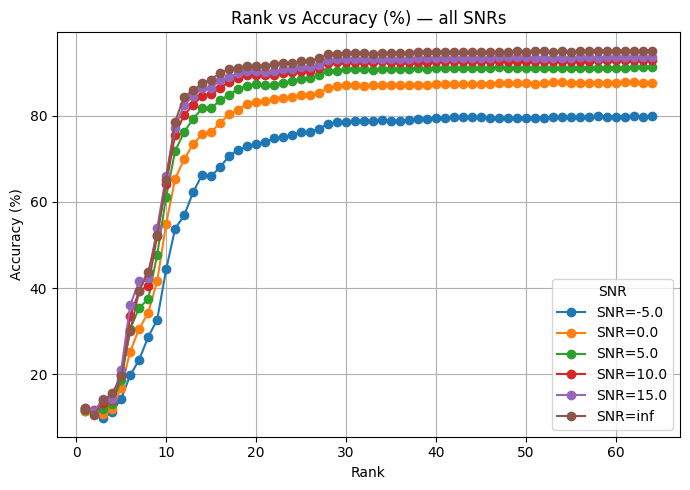


=== Minimum rank to reach acc/max(acc) ≥ 0.95 (acc_all) ===
 snr_eval  min_rank_for_ratio  ratio_target  achieved_ratio_at_min_rank  acc_at_min_rank   max_acc
     -5.0                  25          0.95                    0.955075        76.279070 79.867110
      0.0                  22          0.95                    0.954844        83.831672 87.796235
      5.0                  19          0.95                    0.952427        86.910299 91.251384
     10.0                  18          0.95                    0.953799        88.704319 93.001107
     15.0                  17          0.95                    0.950533        88.947951 93.576966
      inf                  17          0.95                    0.954577        90.764120 95.083056


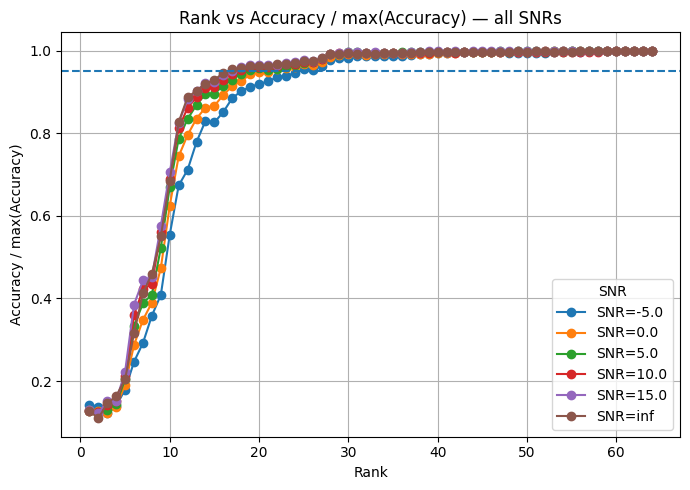

In [47]:
# Normal accuracy plots
summary, ratio_tbl = plot_rank_vs_acc_per_snr(df, include_silence=True, y_mode="acc",plot_per_snr=False)

# Ratio plots + printed table of min rank per SNR to reach 0.8
summary, ratio_tbl = plot_rank_vs_acc_per_snr(
    df,
    include_silence=True,
    y_mode="ratio",
    ratio_target=0.95,
    print_ratio_summary=True,
    plot_per_snr=False,
)

In [48]:
df.groupby(['snr_eval', 'id'])['rank'].nunique().min()

np.int64(64)

In [79]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_min_correct_rank_distributions_grid(
    df: pd.DataFrame,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    normalize: bool = True,
    figsize_per_plot=(5, 4),
    ncols: int = 3,
):
    """
    Grid of plots (one per SNR):
      - histogram of min rank where each sample becomes correct
      - shared x/y limits across all SNR plots
      - overlays mean / median / mode / 95th percentile
      - each subplot has its OWN legend with numeric values
      - x ticks shown on ALL plots and are every other integer
    """

    needed = {snr_col, rank_col, correct_col, id_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- keep only rows where prediction is correct ---
    correct_df = df[df[correct_col].astype(bool)]

    # --- min rank where sample becomes correct ---
    min_rank_df = (
        correct_df
        .groupby([snr_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )

    # --- all samples (to detect never-correct) ---
    all_samples = df[[snr_col, id_col]].drop_duplicates()

    per_sample = all_samples.merge(
        min_rank_df,
        on=[snr_col, id_col],
        how="left",
    )

    # -------------------------------------------------
    # PRECOMPUTE GLOBAL AXIS LIMITS
    # -------------------------------------------------
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        return per_sample

    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())

    ymax = 0.0
    for _, sub in per_sample.groupby(snr_col, sort=False):
        ranks = sub["min_rank"].dropna().astype(int)
        if len(ranks) == 0:
            continue
        counts = ranks.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))

    # -------------------------------------------------
    # GRID SETUP
    # -------------------------------------------------
    snrs = list(per_sample[snr_col].drop_duplicates())
    n_plots = len(snrs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten() if n_plots > 1 else [axes]

    xticks = list(range(xmin, xmax + 1, 2))

    # -------------------------------------------------
    # PLOT PER SNR
    # -------------------------------------------------
    for ax, snr in zip(axes, snrs):
        sub = per_sample[per_sample[snr_col] == snr]
        ranks = sub["min_rank"].dropna().astype(int)

        total = len(sub)
        never = int(sub["min_rank"].isna().sum())
        never_pct = 100.0 * never / total if total else 0.0

        if len(ranks) > 0:
            counts = ranks.value_counts().sort_index()
            x = counts.index.to_numpy()
            y = counts.to_numpy()

            if normalize:
                y = y / y.sum()

            ax.bar(x, y)

            # ---- statistics ----
            mean_rank = float(ranks.mean())
            median_rank = float(ranks.median())
            mode_rank = int(ranks.mode().iloc[0])
            p95_rank = float(ranks.quantile(0.95))

            ax.axvline(mean_rank, linestyle="--", linewidth=2,
                       label=f"Mean = {mean_rank:.2f}",color="C1")
            ax.axvline(median_rank, linestyle="-", linewidth=2,
                       label=f"Median = {median_rank:.2f}", color="C2")
            ax.axvline(mode_rank, linestyle=":", linewidth=2,
                       label=f"Mode = {mode_rank}",color="C3")
            ax.axvline(p95_rank, linestyle="-.", linewidth=2,
                       label=f"P95 = {p95_rank:.2f}",color="C4")

            ax.legend(frameon=False, fontsize=9)

        else:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)

        ax.set_title(
            f"SNR={snr}\nnever: {never}/{total} ({never_pct:.1f}%)",
            fontsize=10,
        )

        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.05)
        ax.grid(axis="y", alpha=0.3)

        # ---- force x ticks on all plots ----
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=90)
        ax.tick_params(axis="x", labelbottom=True)

    # hide unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    # -------------------------------------------------
    # GLOBAL LABELS
    # -------------------------------------------------
    fig.text(0.5, 0.04, "Minimum rank where sample is correct", ha="center")
    fig.text(
        0.04,
        0.5,
        "Probability" if normalize else "Count",
        va="center",
        rotation="vertical",
    )

    fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

    return per_sample



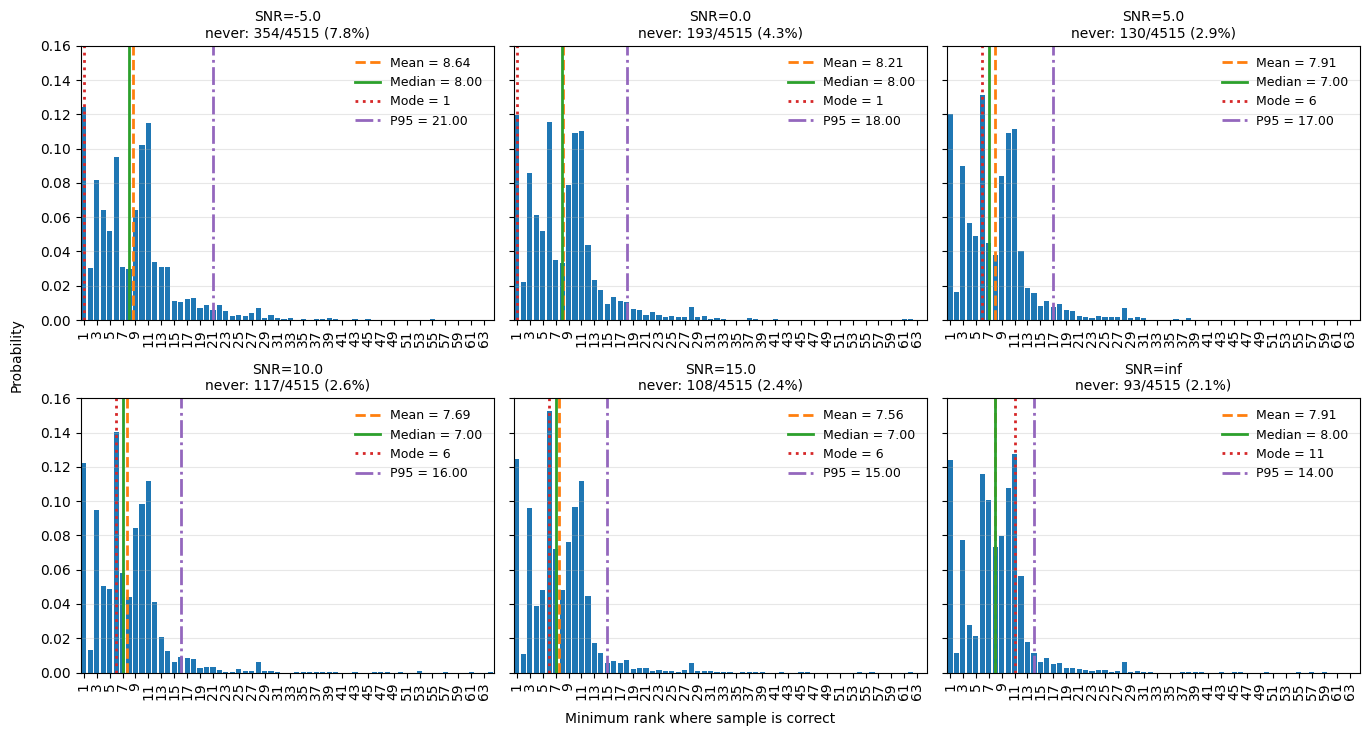

In [80]:
per_sample_min_correct_rank = plot_min_correct_rank_distributions_grid(
    comb_1_df,
    normalize=True,
)

In [85]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_min_correct_rank_distributions_grid_extra(
    df: pd.DataFrame,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    normalize: bool = True,
    figsize_per_plot=(5, 4),
    ncols: int = 3,
    print_post_summary: bool = True,
):
    """
    Grid of plots (one per SNR):
      - histogram of min rank where each sample becomes correct
      - shared x/y limits across all SNR plots
      - overlays mean / median / mode / 95th percentile
      - each subplot has its OWN legend with numeric values
      - x ticks shown on ALL plots and are every other integer

    After plotting, prints a per-SNR summary comparing:
      - oracle(any-rank) accuracy: sample is correct if correct at ANY rank
      - full-rank accuracy: correct at max rank (max(rank_col) in df)
      - delta = oracle - full_rank

    Returns
    -------
    per_sample : pd.DataFrame
        One row per (snr,id) with min_rank (NaN if never correct)
    acc_summary : pd.DataFrame
        Per SNR: acc_any, acc_full_rank, delta, max_rank, n_samples
    """

    needed = {snr_col, rank_col, correct_col, id_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    work = df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col])
    work[correct_col] = work[correct_col].astype(bool)

    # -------------------------
    # Per-sample min-rank table
    # -------------------------
    correct_df = work[work[correct_col]]

    min_rank_df = (
        correct_df
        .groupby([snr_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )

    all_samples = work[[snr_col, id_col]].drop_duplicates()

    per_sample = all_samples.merge(
        min_rank_df,
        on=[snr_col, id_col],
        how="left",
    )

    # -------------------------
    # Global axis limits
    # -------------------------
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        # still compute and print acc summary
        max_rank = int(work[rank_col].max())
        acc_summary = _acc_any_vs_full_rank_summary(
            work,
            snr_col=snr_col,
            id_col=id_col,
            rank_col=rank_col,
            correct_col=correct_col,
            max_rank=max_rank,
        )
        if print_post_summary:
            print("\n=== Oracle(any-rank) vs full-rank accuracy (no correct samples at any SNR) ===")
            print(acc_summary.to_string(index=False))
        return per_sample, acc_summary

    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())

    ymax = 0.0
    for _, sub in per_sample.groupby(snr_col, sort=False):
        ranks = sub["min_rank"].dropna().astype(int)
        if len(ranks) == 0:
            continue
        counts = ranks.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))

    # -------------------------
    # Grid setup
    # -------------------------
    snrs = list(per_sample[snr_col].drop_duplicates())
    n_plots = len(snrs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten() if n_plots > 1 else [axes]

    xticks = list(range(xmin, xmax + 1, 2))

    # -------------------------
    # Plot per SNR
    # -------------------------
    for ax, snr in zip(axes, snrs):
        sub = per_sample[per_sample[snr_col] == snr]
        ranks = sub["min_rank"].dropna().astype(int)

        total = len(sub)
        never = int(sub["min_rank"].isna().sum())
        never_pct = 100.0 * never / total if total else 0.0

        if len(ranks) > 0:
            counts = ranks.value_counts().sort_index()
            x = counts.index.to_numpy()
            y = counts.to_numpy()

            if normalize:
                y = y / y.sum()

            ax.bar(x, y)

            # stats
            mean_rank = float(ranks.mean())
            median_rank = float(ranks.median())
            mode_rank = int(ranks.mode().iloc[0])
            p95_rank = float(ranks.quantile(0.95))

            ax.axvline(mean_rank, linestyle="--", linewidth=2, label=f"Mean = {mean_rank:.2f}",color="C1")
            ax.axvline(median_rank, linestyle="-", linewidth=2, label=f"Median = {median_rank:.2f}",color="C2")
            ax.axvline(mode_rank, linestyle=":", linewidth=2, label=f"Mode = {mode_rank}",color="C3")
            ax.axvline(p95_rank, linestyle="-.", linewidth=2, label=f"P95 = {p95_rank:.2f}",color="C4")

            ax.legend(frameon=False, fontsize=9)
        else:
            ax.text(0.5, 0.5, "No correct samples", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(
            f"SNR={snr}\nnever: {never}/{total} ({never_pct:.1f}%)",
            fontsize=10,
        )

        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.05)
        ax.grid(axis="y", alpha=0.3)

        # force x ticks on all plots
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=90)
        ax.tick_params(axis="x", labelbottom=True)

    # hide unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    # global labels
    fig.text(0.5, 0.04, "Minimum rank where sample is correct", ha="center")
    fig.text(
        0.04,
        0.5,
        "Probability" if normalize else "Count",
        va="center",
        rotation="vertical",
    )

    fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

    # -------------------------
    # Post summary: acc_any vs acc_full(max rank)
    # -------------------------
    max_rank = int(work[rank_col].max())
    acc_summary = _acc_any_vs_full_rank_summary(
        work,
        snr_col=snr_col,
        id_col=id_col,
        rank_col=rank_col,
        correct_col=correct_col,
        max_rank=max_rank,
    )

    if print_post_summary:
        print("\n=== Oracle(any-rank) vs full-rank accuracy ===")
        print(acc_summary.to_string(index=False))

    return per_sample, acc_summary


def _acc_any_vs_full_rank_summary(
    work: pd.DataFrame,
    *,
    snr_col: str,
    id_col: str,
    rank_col: str,
    correct_col: str,
    max_rank: int,
) -> pd.DataFrame:
    # one row per (snr,id): ever correct at any rank?
    any_correct = (
        work.groupby([snr_col, id_col], sort=False)[correct_col]
            .any()
            .reset_index(name="any_correct")
    )

    # one row per (snr,id): correct at max rank?
    full = (
        work[work[rank_col] == max_rank]
        .groupby([snr_col, id_col], sort=False)[correct_col]
        .any()
        .reset_index(name="correct_at_max_rank")
    )

    merged = any_correct.merge(full, on=[snr_col, id_col], how="left")
    merged["correct_at_max_rank"] = merged["correct_at_max_rank"].fillna(False)

    out = (
        merged.groupby(snr_col, sort=False)
        .agg(
            n_samples=(id_col, "count"),
            acc_any=("any_correct", "mean"),
            acc_full_rank=("correct_at_max_rank", "mean"),
        )
        .reset_index()
    )

    out["acc_any"] = out["acc_any"] * 100
    out["acc_full_rank"] = out["acc_full_rank"] * 100
    out["delta_any_minus_full"] = out["acc_any"] - out["acc_full_rank"]
    out["max_rank"] = max_rank

    # nice column order
    out = out[[snr_col, "n_samples", "max_rank", "acc_any", "acc_full_rank", "delta_any_minus_full"]]
    return out


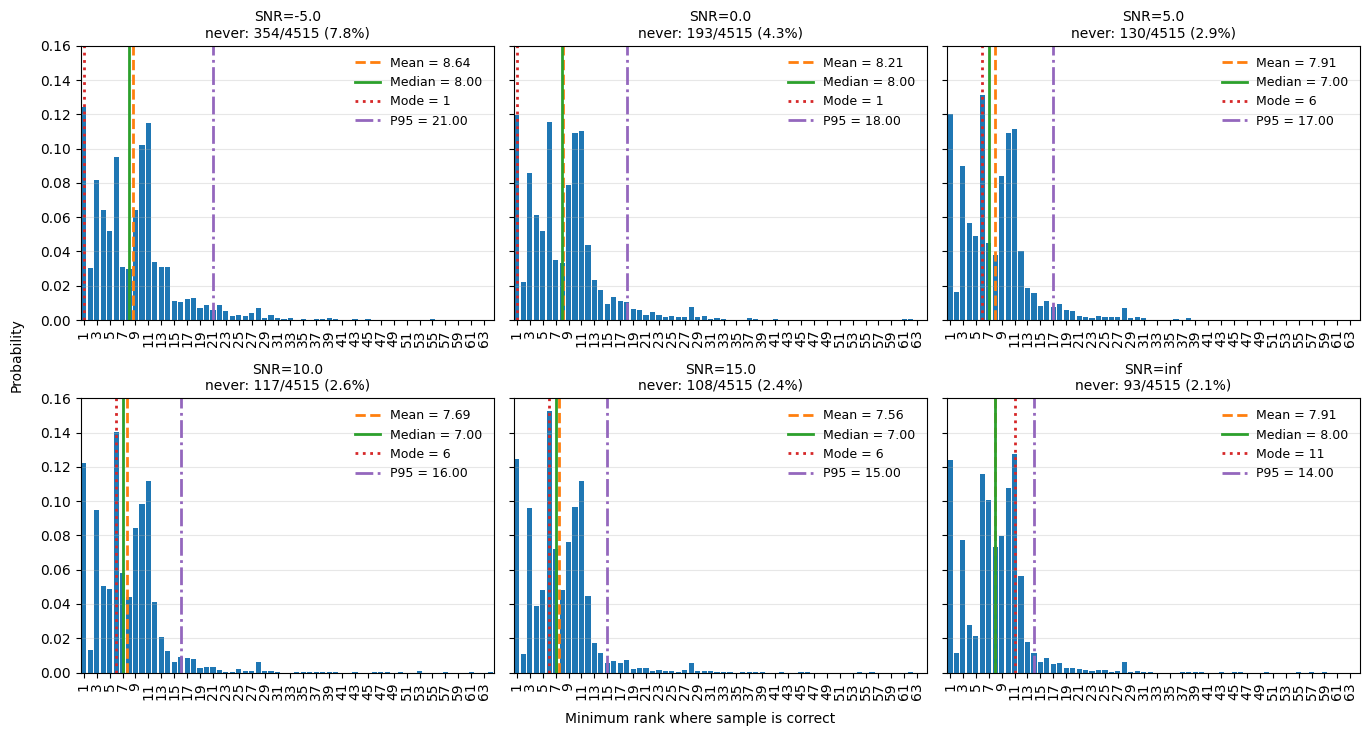


=== Oracle(any-rank) vs full-rank accuracy ===
 snr_eval  n_samples  max_rank   acc_any  acc_full_rank  delta_any_minus_full
     -5.0       4515        64 92.159468      79.844961             12.314507
      0.0       4515        64 95.725360      87.685493              8.039867
      5.0       4515        64 97.120709      91.251384              5.869324
     10.0       4515        64 97.408638      93.001107              4.407530
     15.0       4515        64 97.607973      93.554817              4.053156
      inf       4515        64 97.940199      95.083056              2.857143


In [86]:
per_sample, acc_summary = plot_min_correct_rank_distributions_grid_extra(
    comb_1_df,
    snr_col="snr_eval",
    rank_col="rank",
    correct_col="correct",
    id_col="id",
    normalize=True,
    ncols=3,                 # e.g. 2x3 grid for 6 SNR values
    figsize_per_plot=(5, 4),
    print_post_summary=True, # prints the oracle vs full-rank table
)

In [51]:
bad = (
    comb_1_df
    .groupby(['snr_eval', 'id'])['target']
    .nunique()
)
print("Bad IDs:", (bad > 1).sum())

Bad IDs: 0


In [52]:
def inspect_sample(df, snr, sample_id):
    sub = (
        df[(df["snr_eval"] == snr) & (df["id"] == sample_id)]
        .sort_values("rank")
    )
    return sub[["rank", "correct"]]

inspect_sample(comb_1_df, -5.0, 32)

,rank,correct
32,1,False
27122,2,False
54212,3,False
81302,4,False
108392,5,False
...,...,...
1598342,60,False
1625432,61,False
1652522,62,False
1679612,63,False


In [53]:
import pandas as pd
import numpy as np

def diagnose_non_monotonic_correctness(
    df: pd.DataFrame,
    *,
    snr_col="snr_eval",
    id_col="id",
    rank_col="rank",
    correct_col="correct",
):
    work = df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col])
    work[correct_col] = work[correct_col].astype(bool)

    # wide matrix: rows=(snr,id), cols=rank, values=correct
    mat = (
        work.pivot_table(
            index=[snr_col, id_col],
            columns=rank_col,
            values=correct_col,
            aggfunc="first",
        )
        .sort_index(axis=1)
    )

    ranks = mat.columns.to_numpy()
    if len(ranks) < 2:
        raise ValueError("Need at least 2 ranks to diagnose monotonicity.")

    # forward monotone check: once correct, should remain correct
    arr = mat.to_numpy(dtype=float)  # NaN if missing
    # treat NaN as missing; we'll mask them out
    valid = ~np.isnan(arr)
    arr_bool = np.where(valid, arr > 0.5, False)

    # For each row, compute if there exists i<j with correct[i]=1 and correct[j]=0
    # A simple way: for each position j, check if any earlier correct and current incorrect
    prefix_any_correct = np.maximum.accumulate(arr_bool, axis=1)
    violation_matrix = prefix_any_correct & (~arr_bool)  # True where a violation occurs
    # But ignore positions where current is missing
    violation_matrix = violation_matrix & valid

    has_violation = violation_matrix.any(axis=1)

    # Wrong at max rank but correct at some other rank
    max_rank = ranks.max()
    is_correct_at_max = mat[max_rank].fillna(False).astype(bool)
    is_correct_any = mat.fillna(False).any(axis=1)
    wrong_at_max_but_correct_somewhere = (~is_correct_at_max) & (is_correct_any)

    summary = pd.DataFrame({
        "n_samples": mat.shape[0],
        "n_with_any_violation": has_violation.sum(),
        "pct_with_any_violation": 100 * has_violation.mean(),
        "n_wrong_at_max_but_correct_somewhere": wrong_at_max_but_correct_somewhere.sum(),
        "pct_wrong_at_max_but_correct_somewhere": 100 * wrong_at_max_but_correct_somewhere.mean(),
        "max_rank": max_rank,
    }, index=["ALL"])

    # Per SNR breakdown
    idx = mat.index
    snrs = idx.get_level_values(0)
    per_snr = []
    for snr in snrs.unique():
        mask = (snrs == snr)
        per_snr.append({
            snr_col: snr,
            "n_samples": int(mask.sum()),
            "pct_with_any_violation": float(has_violation[mask].mean() * 100),
            "pct_wrong_at_max_but_correct_somewhere": float(wrong_at_max_but_correct_somewhere[mask].mean() * 100),
        })
    per_snr = pd.DataFrame(per_snr).sort_values(snr_col)

    # Return some example IDs to inspect
    viol_index = mat.index[has_violation]
    weird_index = mat.index[wrong_at_max_but_correct_somewhere]

    examples = {
        "violation_examples": viol_index[:20].tolist(),
        "wrong_at_max_but_correct_somewhere_examples": weird_index[:20].tolist(),
    }

    return mat, summary, per_snr, examples


In [54]:
mat, summary, per_snr, examples = diagnose_non_monotonic_correctness(comb_1_df)
print(summary.to_string(index=False))
print(per_snr.to_string(index=False))
print(examples)

 n_samples  n_with_any_violation  pct_with_any_violation  n_wrong_at_max_but_correct_somewhere  pct_wrong_at_max_but_correct_somewhere  max_rank
     27090                 10605               39.147287                                  1695                                6.256921        64
 snr_eval  n_samples  pct_with_any_violation  pct_wrong_at_max_but_correct_somewhere
     -5.0       4515               49.501661                               12.314507
      0.0       4515               42.635659                                8.039867
      5.0       4515               39.158361                                5.869324
     10.0       4515               36.389812                                4.407530
     15.0       4515               36.478405                                4.053156
      inf       4515               30.719823                                2.857143
{'violation_examples': [(-5.0, 1), (-5.0, 8), (-5.0, 11), (-5.0, 13), (-5.0, 17), (-5.0, 31), (-5.0, 32), (-5.0, 37

In [55]:
def show_sample_correctness_curve(mat, snr, sample_id, *, snr_col="snr_eval", id_col="id"):
    row = mat.loc[(snr, sample_id)]
    print(row.astype("boolean"))  # True/False/NA

In [56]:
snr, sid = examples["wrong_at_max_but_correct_somewhere_examples"][1]
show_sample_correctness_curve(mat, snr, sid)

rank
1     False
2     False
3     False
4     False
5     False
      ...  
60    False
61    False
62    False
63    False
64    False
Name: (-5.0, 66), Length: 64, dtype: boolean


In [57]:
import numpy as np
import pandas as pd


def compute_flip_counts(
    df: pd.DataFrame,
    *,
    snr_col="snr_eval",
    id_col="id",
    rank_col="rank",
    correct_col="correct",
):
    """
    Returns one row per (snr_eval, id) with:
      - n_flips: number of correctness flips across ranks
      - n_ranks: number of evaluated ranks
      - ever_correct
      - correct_at_max_rank
    """

    work = df.copy()
    work[rank_col] = pd.to_numeric(work[rank_col])
    work[correct_col] = work[correct_col].astype(int)

    rows = []

    for (snr, sid), sub in work.groupby([snr_col, id_col], sort=False):
        sub = sub.sort_values(rank_col)

        y = sub[correct_col].to_numpy()

        # count adjacent flips
        n_flips = int(np.sum(y[1:] != y[:-1]))

        rows.append({
            snr_col: snr,
            id_col: sid,
            "n_flips": n_flips,
            "n_ranks": len(y),
            "ever_correct": bool(y.any()),
            "correct_at_max_rank": bool(y[-1]),
        })

    return pd.DataFrame(rows)

In [58]:
flips_df = compute_flip_counts(comb_1_df)

In [59]:
import numpy as np
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt


def plot_flip_histograms(
    flips_df,
    *,
    snr_col="snr_eval",
    flip_col="n_flips",
    max_flips=20,        # last bin collects >= max_flips
    normalize=True,      # probability instead of count
    figsize=(6, 4),
):
    snrs = sorted(flips_df[snr_col].unique())

    # fixed bins: 0,1,2,...,max_flips
    bins = np.arange(0, max_flips + 1)

    # ---- precompute histograms and global y-limit ----
    histograms = {}
    global_max_y = 0.0

    for snr in snrs:
        vals = flips_df.loc[flips_df[snr_col] == snr, flip_col]
        vals = vals.clip(upper=max_flips)

        counts = (
            vals.value_counts()
                .reindex(bins, fill_value=0)
                .sort_index()
        )

        if normalize:
            counts = counts / counts.sum()

        histograms[snr] = counts
        global_max_y = max(global_max_y, counts.max())

    # ---- plot ----
    for snr in snrs:
        counts = histograms[snr]

        plt.figure(figsize=figsize)
        plt.bar(bins, counts.values, width=0.9)

        plt.xlim(-0.5, max_flips + 0.5)
        plt.ylim(0, global_max_y * 1.05)

        plt.xticks(bins)
        plt.xlabel("Number of correctness flips across ranks")
        plt.ylabel("Probability" if normalize else "Number of samples")
        plt.title(f"SNR={snr} — flip count distribution")

        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

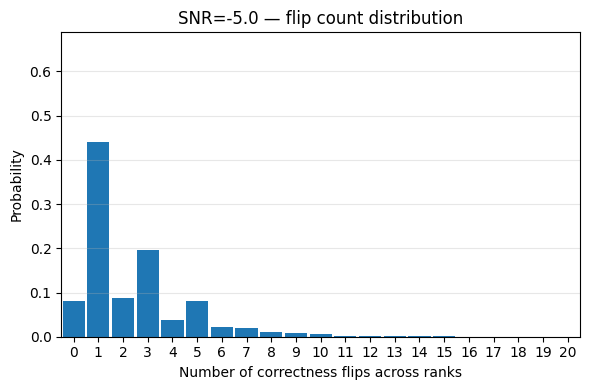

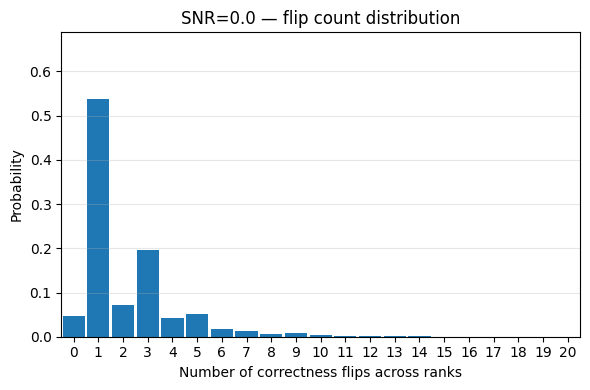

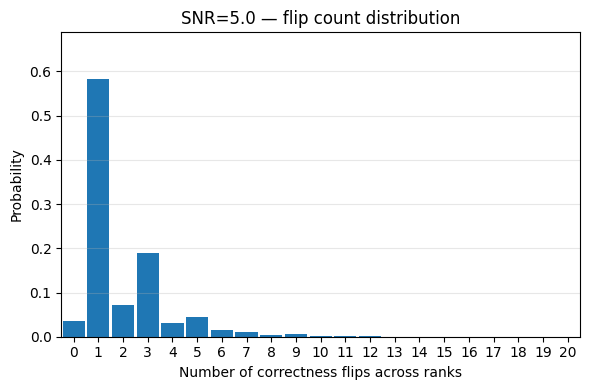

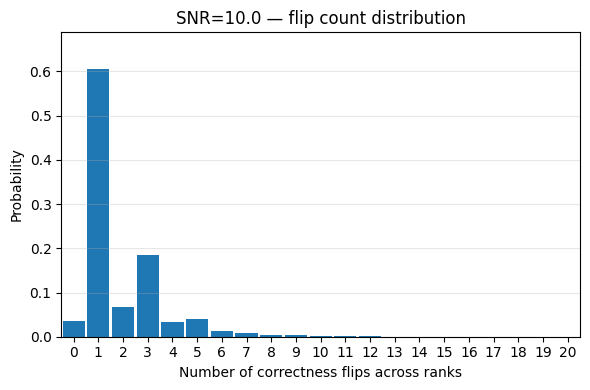

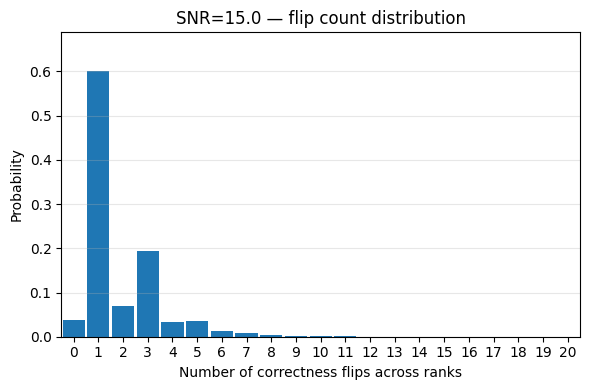

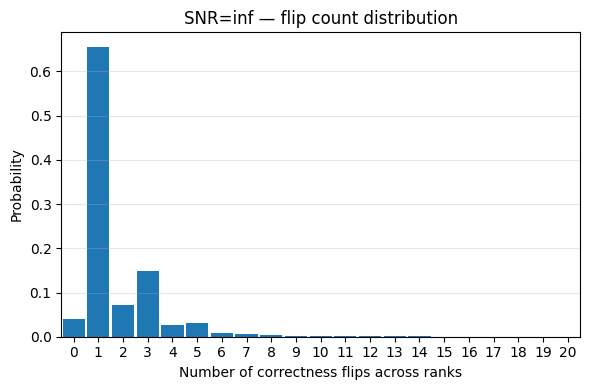

In [60]:
plot_flip_histograms(flips_df)

In [61]:
g = (
    comb_1_df
    .assign(is_silence=comb_1_df["label"] == "SILENCE")
    .groupby(["rank", "snr_eval"])
)

acc_all = g["correct"].mean() * 100

acc_non_silence = (
    comb_1_df[comb_1_df["label"] != "SILENCE"]
    .groupby(["rank", "snr_eval"])["correct"]
    .mean()
    * 100
)

summary = (
    pd.concat(
        {
            "acc_all": acc_all,
            "acc_non_silence": acc_non_silence,
        },
        axis=1,
    )
    .assign(acc_diff=lambda df: df["acc_all"] - df["acc_non_silence"])
)

summary

acc_all  acc_non_silence  acc_diff
rank snr_eval                                      
1    -5.0      11.428571        11.048917  0.379654
      0.0      11.450720        11.073254  0.377466
      5.0      11.650055        11.292285  0.357770
      10.0     11.893688        11.559990  0.333697
      15.0     12.181617        11.876369  0.305248
...                  ...              ...       ...
64    0.0      87.685493        86.468727  1.216766
      5.0      91.251384        90.386955  0.864429
      10.0     93.001107        92.309564  0.691543
      15.0     93.554817        92.917985  0.636832
      inf      95.083056        94.597226  0.485831

[384 rows x 3 columns]